In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
class PinnHeatEq(nn.Module):
    def __init__(self):
        super().__init__()
        self.couche_entree = nn.Linear(2, 50)
        self.couche_cachee1 = nn.Linear(50, 50)
        self.couche_cachee2 = nn.Linear(50, 50)
        self.couche_sortie = nn.Linear(50, 1)

    def forward(self, x):
        x = torch.tanh(self.couche_entree(x))
        x = torch.tanh(self.couche_cachee1(x))
        x = torch.tanh(self.couche_cachee2(x))
        return self.couche_sortie(x)

In [3]:
t_min, t_max = 0.0, 1.0
x_min, x_max = 0.0, 1.0


def generer_points_collocation(n_pde):
    t_colloc = torch.rand(n_pde, 1) * (t_max - t_min) + t_min
    x_colloc = torch.rand(n_pde, 1) * (x_max - x_min) + x_min
    return t_colloc.float(), x_colloc.float()

In [4]:
""" Dans un PINN HARD , uniquement la CLP LOSS est necessaire  et on definit A et B tq U = A + B * N 
satisfait toutes les conditions"""

def A(t, x):
    return torch.sin(2 * torch.pi * x)


def B(t, x):
    return t * x * (1 - x)


class SolutionHard(nn.Module):
    def __init__(self, reseau):
        super().__init__()
        self.reseau = reseau

    def forward(self, entrees):
        t, x = entrees[:, :1], entrees[:, 1:]
        return A(t, x) + B(t, x) * self.reseau(entrees)


def calc_clp_loss(model, t_colloc, x_colloc, alpha):
 #   lambda_reg = 0.00000001
    t_colloc.requires_grad_(True)
    x_colloc.requires_grad_(True)

    u_pred = model(torch.cat([t_colloc, x_colloc], dim=1))

    u_t = torch.autograd.grad(
        outputs=u_pred,
        inputs=t_colloc,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
    )[0]

    u_x = torch.autograd.grad(
        outputs=u_pred,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
    )[0]

    u_xx = torch.autograd.grad(
        outputs=u_x,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
    )[0]

    u_xxx = torch.autograd.grad(
        outputs=u_xx,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(u_xx),
        create_graph=True,
    )[0]

    residu = u_t - alpha * u_xx
    #return torch.mean(residu ** 2) + lambda_reg * torch.mean(u_xxx ** 2)
    return torch.mean(residu ** 2) 

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

alpha = 0.0005

reseau = PinnHeatEq().to(device)
modele = SolutionHard(reseau).to(device)
optimizer = optim.Adam(modele.parameters(), lr=0.001)

t_colloc, x_colloc = generer_points_collocation(12000)
t_colloc, x_colloc = t_colloc.to(device), x_colloc.to(device)

mps


In [6]:
epochs = 2000

for epoch in range(epochs):
    optimizer.zero_grad()

    loss_clp = calc_clp_loss(modele, t_colloc, x_colloc, alpha)
    loss_clp.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoque {epoch:05d} | CLP: {loss_clp.item():.2e}")


def closure():
    optimizer.zero_grad()
    
    loss_clp = calc_clp_loss(modele, t_colloc, x_colloc, alpha)

    loss_clp.backward()
    return loss_clp

lbfgs_epochs = 500
optimizer = optim.LBFGS(modele.parameters(), line_search_fn="strong_wolfe",max_iter = 20)
for epoch in range(lbfgs_epochs):
    loss = optimizer.step(closure)
    if epoch % 100 == 0:
        print(f"Epoque LBFGS {epoch:05d} | "
              f"Loss totale: {loss.item():.2e}")


Epoque 00000 | CLP: 2.36e-04


Epoque 00100 | CLP: 3.65e-06


Epoque 00200 | CLP: 3.54e-06


Epoque 00300 | CLP: 3.50e-06


Epoque 00400 | CLP: 3.47e-06


...

Epoque LBFGS 00000 | Loss totale: 3.17e-08


Epoque LBFGS 00100 | Loss totale: 3.17e-08


Epoque LBFGS 00200 | Loss totale: 3.17e-08


Epoque LBFGS 00300 | Loss totale: 3.17e-08


Epoque LBFGS 00400 | Loss totale: 3.17e-08


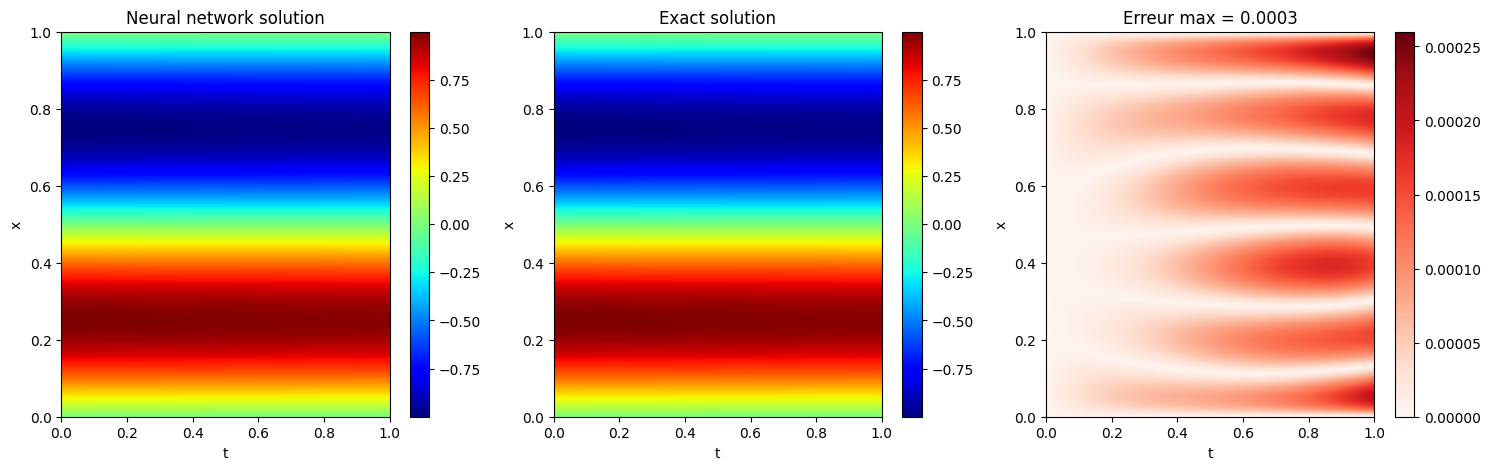

In [7]:
import sys; sys.path.append("..")
import numpy as np
from pinnplot import plot_solution

u_exact = lambda t, x: np.sin(2*np.pi*x) * np.exp(-(2*np.pi)**2 * alpha * t)

plot_solution(modele, u_exact)